<a href="https://colab.research.google.com/github/Jubayer934/Sexual_Harassment/blob/main/Latest1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# --------------------------
✅ Step 1: Install Required Libraries
# --------------------------

In [ ]:
from transformers import VideoMAEFeatureExtractor, VideoMAEForVideoClassification

In [ ]:
!pip install decord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 42.8 MB/s eta 0:00:00


# --------------------------
✅ Step 2: Load Pretrained ViViT Model + Feature Extractor
# --------------------------

In [ ]:
# Load feature extractor and pretrained model
feature_extractor = VideoMAEFeatureExtractor.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")
model = VideoMAEForVideoClassification.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")

#  Prepares (resizes, normalizes) video frames for the model.
# This is the pretrained ViViT model, already trained on the Kinetics-400 dataset.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/videomae/feature_extraction_videomae.py:30: FutureWarning: The class VideoMAEFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use VideoMAEImageProcessor instead.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

# --------------------------
✅ Step 3: Dataset
# --------------------------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import zipfile
import os

# Path to the zip file in Drive
zip_path = "/content/drive/MyDrive/ModelTrain/Sexual_Harassment/dataset/Harassment_dataset.zip"

# Unzip it to /content/
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/Sexual_Harassment_Dataset")

# Set dataset path
dataset_path = "/content/Sexual_Harassment_Dataset"

In [ ]:
import os

# List top-level files/folders
print(os.listdir("/content/Sexual_Harassment_Dataset"))

# If it's nested, explore further:
for root, dirs, files in os.walk("/content/Sexual_Harassment_Dataset"):
    print("Root:", root)
    print("Dirs:", dirs)
    print("Files:", files[:5])  # just print the first 5 files
    print("===")

['Harassment_dataset']
Root: /content/Sexual_Harassment_Dataset
Dirs: ['Harassment_dataset']
Files: []
===
Root: /content/Sexual_Harassment_Dataset/Harassment_dataset
Dirs: ['Harassment', 'No_Harassment']
Files: []
===
Root: /content/Sexual_Harassment_Dataset/Harassment_dataset/Harassment
Dirs: []
Files: ['haras_75.mp4', 'haras_238.mp4', 'haras_135.mp4', 'haras_157.mp4', 'haras_176.mp4']
===
Root: /content/Sexual_Harassment_Dataset/Harassment_dataset/No_Harassment
Dirs: []
Files: ['no_haras_22.mp4', 'no_haras_132.mp4', 'no_haras_154.mp4', 'no_haras_168.mp4', 'no_haras_33.mp4']
===


In [ ]:
import os
from decord import VideoReader, cpu

dataset_path = "/content/Sexual_Harassment_Dataset/Harassment_dataset"

def count_unreadable_videos(root_dir):
    unreadable = []
    total = 0

    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.lower().endswith(".mp4"):
                total += 1
                video_path = os.path.join(root, file)

                try:
                    vr = VideoReader(video_path, ctx=cpu(0))
                    if len(vr) == 0:
                        unreadable.append(video_path)
                except:
                    unreadable.append(video_path)

    print(f"📦 Total videos found: {total}")
    print(f"❌ Unreadable videos: {len(unreadable)}\n")

    if unreadable:
        print("List of unreadable videos:")
        for path in unreadable:
            print(path)

count_unreadable_videos(dataset_path)

📦 Total videos found: 600
❌ Unreadable videos: 0



In [ ]:
import os

dataset_path = "/content/Sexual_Harassment_Dataset/Harassment_dataset"

def count_videos_in_classes(root_dir):
    class_counts = {}
    for class_name in os.listdir(root_dir):
        class_dir = os.path.join(root_dir, class_name)
        if os.path.isdir(class_dir):
            video_count = 0
            for root, dirs, files in os.walk(class_dir):
                for file in files:
                    if file.lower().endswith(".mp4"):
                        video_count += 1
            class_counts[class_name] = video_count
    return class_counts

class_video_counts = count_videos_in_classes(dataset_path)

print("Video counts per class:")
for class_name, count in class_video_counts.items():
    print(f"- {class_name}: {count}")

Video counts per class:
- Harassment: 282
- No_Harassment: 318


In [ ]:
import os
from decord import VideoReader, cpu
import numpy as np

def get_video_paths_labels(root_dir):
    video_paths = []
    labels = []
    label_map = {'No_Harassment': 0, 'Harassment': 1}
    unreadable_videos_count = 0

    for cls in label_map:
        cls_folder = os.path.join(root_dir, cls)
        for fname in os.listdir(cls_folder):
            if fname.endswith('.mp4'):
                video_path = os.path.join(cls_folder, fname)
                try:
                    # Attempt to read the video to check if it's accessible and readable
                    vr = VideoReader(video_path, ctx=cpu(0))
                    _ = len(vr) # Check if length can be obtained
                    video_paths.append(video_path)
                    labels.append(label_map[cls])
                except Exception as e:
                    print(f"Warning: Could not read video {video_path}. Skipping. Error: {e}")
                    unreadable_videos_count += 1

    print(f"\nFound {unreadable_videos_count} unreadable videos that were skipped.")
    return video_paths, labels, label_map

video_paths, labels, label_map = get_video_paths_labels("/content/Sexual_Harassment_Dataset/Harassment_dataset")


Found 0 unreadable videos that were skipped.


# ---------------------
Stap 4: Split the dataset
# ---------------------

In [ ]:
from sklearn.model_selection import train_test_split

train_paths, val_paths, train_labels, val_labels = train_test_split(
    video_paths, labels, test_size=0.20, stratify=labels, random_state=42
)

In [ ]:
import os

# Display the first training video path
print("First training video:", train_paths[0])
print("\nFirst 5 training videos:")
for i in range(min(5, len(val_paths))):
    print(train_paths[i])

# Display the first 5 validation video paths
print("\nFirst 5 validation videos:")
for i in range(min(5, len(val_paths))):
    print(val_paths[i])

First training video: /content/Sexual_Harassment_Dataset/Harassment_dataset/Harassment/haras_168.mp4

First 5 training videos:
/content/Sexual_Harassment_Dataset/Harassment_dataset/Harassment/haras_168.mp4
/content/Sexual_Harassment_Dataset/Harassment_dataset/No_Harassment/no_haras_260.mp4
/content/Sexual_Harassment_Dataset/Harassment_dataset/Harassment/haras_125.mp4
/content/Sexual_Harassment_Dataset/Harassment_dataset/No_Harassment/no_haras_270.mp4
/content/Sexual_Harassment_Dataset/Harassment_dataset/Harassment/haras_169.mp4

First 5 validation videos:
/content/Sexual_Harassment_Dataset/Harassment_dataset/No_Harassment/no_haras_53.mp4
/content/Sexual_Harassment_Dataset/Harassment_dataset/Harassment/haras_142.mp4
/content/Sexual_Harassment_Dataset/Harassment_dataset/Harassment/haras_179.mp4
/content/Sexual_Harassment_Dataset/Harassment_dataset/Harassment/haras_273.mp4
/content/Sexual_Harassment_Dataset/Harassment_dataset/No_Harassment/no_haras_204.mp4


In [ ]:
from torch.utils.data import Dataset
from decord import VideoReader, cpu
import numpy as np
from torchvision import transforms
from PIL import Image

class HarassmentDataset(Dataset):
    def __init__(self, video_paths, labels, feature_extractor, num_frames=16, is_train=True):
        self.video_paths = video_paths
        self.labels = labels
        self.feature_extractor = feature_extractor
        self.num_frames = num_frames
        self.is_train = is_train

        # Define augmentation pipeline (only for training)
        self.augment = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.RandomRotation(5),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
      vr = VideoReader(self.video_paths[idx], ctx=cpu(0))
      total_frames = len(vr)
      indices = np.linspace(0, total_frames - 1, min(self.num_frames, total_frames)).astype(int)
      frames = vr.get_batch(indices).asnumpy()

      if self.is_train:
          frames = [self.augment(frame) for frame in frames]
      else:
          frames = [transforms.ToTensor()(frame) for frame in frames]

      # Convert tensors back to uint8 numpy for feature extractor
      frames = [(frame.permute(1, 2, 0).numpy() * 255).astype(np.uint8) for frame in frames]

      inputs = self.feature_extractor(frames, return_tensors="pt")
      return inputs["pixel_values"].squeeze(0), self.labels[idx]


# ----------------------
Step 5: Create DataLoaders
# ----------------------

In [ ]:
from torch.utils.data import DataLoader

train_dataset = HarassmentDataset(train_paths, train_labels, feature_extractor)
val_dataset = HarassmentDataset(val_paths, val_labels, feature_extractor)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=2)

In [ ]:
for i, (pixel_values, labels) in enumerate(train_loader):
    print(f"Batch {i+1}")
    print("Pixel values shape:", pixel_values.shape)  # Should be (B, T, C, H, W) or (B, 3, 16, 224, 224) after permute
    print("Labels:", labels)
    if i == 1:  # print only first 2 batches
        break

Batch 1
Pixel values shape: torch.Size([2, 16, 3, 224, 224])
Labels: tensor([1, 0])
Batch 2
Pixel values shape: torch.Size([2, 16, 3, 224, 224])
Labels: tensor([0, 1])


In [ ]:
for i, (pixel_values, labels) in enumerate(val_loader):
    print(f"Validation Batch {i+1}")
    print("Pixel values shape:", pixel_values.shape)
    print("Labels:", labels)
    if i == 1:
        break

Validation Batch 1
Pixel values shape: torch.Size([2, 16, 3, 224, 224])
Labels: tensor([0, 1])
Validation Batch 2
Pixel values shape: torch.Size([2, 16, 3, 224, 224])
Labels: tensor([1, 1])


In [ ]:
for label_idx in labels:
    for class_name, idx in label_map.items():
        if idx == label_idx.item():
            print(f"Label {label_idx.item()} corresponds to class: {class_name}")

Label 1 corresponds to class: Harassment
Label 1 corresponds to class: Harassment


In [ ]:
# From (B, T, C, H, W) to (B, C, T, H, W)

for pixel_values, labels in train_loader:
    print("Before permute:", pixel_values.shape)
    pixel_values = pixel_values.permute(0, 2, 1, 3, 4)
    print("After permute:", pixel_values.shape)
    break

Before permute: torch.Size([2, 16, 3, 224, 224])
After permute: torch.Size([2, 3, 16, 224, 224])


In [ ]:
print(pixel_values.shape)

torch.Size([2, 3, 16, 224, 224])


In [ ]:
print(f"Number of training videos: {len(train_dataset)}")
print(f"Number of validation videos: {len(val_dataset)}")

Number of training videos: 480
Number of validation videos: 120


In [ ]:
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Number of training batches: 240
Number of validation batches: 60


In [ ]:
print(f"Number of classes: {len(label_map)}")

Number of classes: 2


In [ ]:
print(f"Label map: {label_map}")

Label map: {'No_Harassment': 0, 'Harassment': 1}


# ---------
Step 6: Adjust Model Output Layer
# ---------

In [ ]:
import torch.nn as nn

num_classes = len(label_map)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model.config.num_labels = num_classes

# ---------------
Step 7: Train the Dataset
# ---------------

In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import classification_report
from tqdm import tqdm
import os

# =====================
# Device Setup
# =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"✅ Using device: {device}")

# =====================
# Loss, Optimizer, Scheduler
# =====================
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=3) # Removed verbose=True

# =====================
# Training Settings
# =====================
num_epochs = 20
patience = 5
patience_counter = 0
best_val_loss = float("inf")

# =====================
# Metric Storage
# =====================
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Reverse label map for readable class names
idx_to_class = {v: k for k, v in label_map.items()}

# =====================
# Checkpoint Paths
# =====================
checkpoint_dir = "/content/drive/MyDrive/ModelTrain/Sexual_Harassment/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
latest_ckpt = os.path.join(checkpoint_dir, "last_checkpoint.pth")
best_model_path = os.path.join(checkpoint_dir, "best_model.pth")

# =====================
# Resume Training (if checkpoint exists)
# =====================
start_epoch = 0

if os.path.exists(latest_ckpt):
    checkpoint = torch.load(latest_ckpt, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]

    # restore history
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    train_accuracies = checkpoint.get("train_accuracies", [])
    val_accuracies = checkpoint.get("val_accuracies", [])

    print(f"✅ Resuming training from epoch {start_epoch}")
    print(f"📊 Previous best validation loss: {best_val_loss:.4f}")

    if start_epoch > 0:
        print("\n📋 Previous Training History:")
        print("Epoch | Train Loss | Val Loss | Train Acc | Val Acc")
        for i in range(start_epoch):
            print(f"{i+1:5d} | {train_losses[i]:10.4f} | {val_losses[i]:8.4f} | "
                  f"{train_accuracies[i]:9.2f}% | {val_accuracies[i]:7.2f}%")

# =====================
# Training Loop
# =====================
for epoch in range(start_epoch, num_epochs):
    print(f"\n🎯 Epoch {epoch + 1}/{num_epochs}")

    # ----- Training -----
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for pixel_values, labels in tqdm(train_loader, desc="Training", unit="batch"):
        pixel_values, labels = pixel_values.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values=pixel_values)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.logits, 1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()

    avg_train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # ----- Validation -----
    model.eval()
    val_running_loss, correct_val, total_val = 0.0, 0, 0
    true_labels, pred_labels = [], []

    with torch.no_grad():
        for pixel_values, labels in tqdm(val_loader, desc="Validating", unit="batch"):
            pixel_values, labels = pixel_values.to(device), labels.to(device)
            outputs = model(pixel_values=pixel_values)
            loss = criterion(outputs.logits, labels)

            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.logits, 1)

            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

            true_labels.extend(labels.cpu().numpy())
            pred_labels.extend(predicted.cpu().numpy())

    avg_val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    # ----- Print Epoch Metrics -----
    print(f"📉 Train Loss: {avg_train_loss:.4f} | 📈 Val Loss: {avg_val_loss:.4f} | "
          f"✅ Train Acc: {train_acc:.2f}% | ✅ Val Acc: {val_acc:.2f}%")

    # ----- Scheduler Step -----
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"📉 Current Learning Rate: {current_lr:.6f}")

    # ----- Save Best Model -----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        print(f"🌟 Best model updated! Val Loss: {best_val_loss:.4f}")
    else:
        patience_counter += 1
        print(f"⚠️ No improvement. Best so far: {best_val_loss:.4f}")
        if patience_counter >= patience:
            print("⏹️ Early stopping triggered!")
            break

    # ----- Save Checkpoint -----
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "best_val_loss": best_val_loss
    }, latest_ckpt)

    print(f"💾 Saved latest checkpoint for epoch {epoch}")

    # ----- Classification Report -----
    print("\n🧾 Classification Report:")
    print(classification_report(
        [idx_to_class[i] for i in true_labels],
        [idx_to_class[i] for i in pred_labels],
        digits=3
    ))

print(f"\n🎯 Training completed. Best Validation Loss: {best_val_loss:.4f}")

✅ Using device: cuda
✅ Resuming training from epoch 11
📊 Previous best validation loss: 0.2713

📋 Previous Training History:
Epoch | Train Loss | Val Loss | Train Acc | Val Acc
    1 |     0.5940 |   0.5067 |     67.71% |   72.50%
    2 |     0.3792 |   0.3212 |     83.33% |   87.50%
    3 |     0.2871 |   0.3238 |     87.50% |   88.33%
    4 |     0.1793 |   0.4249 |     92.92% |   85.00%
    5 |     0.1167 |   0.4448 |     96.25% |   83.33%
    6 |     0.1272 |   0.3579 |     94.17% |   87.50%
    7 |     0.0184 |   0.2713 |     99.38% |   87.50%
    8 |     0.0068 |   0.2871 |    100.00% |   90.00%
    9 |     0.0057 |   0.2832 |    100.00% |   91.67%
   10 |     0.0037 |   0.3000 |    100.00% |   90.00%
   11 |     0.0028 |   0.2856 |    100.00% |   91.67%

🎯 Epoch 12/20


Validating: 100%|██████████| 60/60 [01:29<00:00,  1.50s/batch]


📉 Train Loss: 0.0022 | 📈 Val Loss: 0.3390 | ✅ Train Acc: 100.00% | ✅ Val Acc: 90.00%
📉 Current Learning Rate: 0.000001
⚠️ No improvement. Best so far: 0.2713
💾 Saved latest checkpoint for epoch 11

🧾 Classification Report:
               precision    recall  f1-score   support

   Harassment      0.867     0.929     0.897        56
No_Harassment      0.933     0.875     0.903        64

     accuracy                          0.900       120
    macro avg      0.900     0.902     0.900       120
 weighted avg      0.902     0.900     0.900       120


🎯 Epoch 13/20


Validating: 100%|██████████| 60/60 [01:30<00:00,  1.50s/batch]


📉 Train Loss: 0.0017 | 📈 Val Loss: 0.3759 | ✅ Train Acc: 100.00% | ✅ Val Acc: 88.33%
📉 Current Learning Rate: 0.000001
⚠️ No improvement. Best so far: 0.2713
💾 Saved latest checkpoint for epoch 12

🧾 Classification Report:
               precision    recall  f1-score   support

   Harassment      0.850     0.911     0.879        56
No_Harassment      0.917     0.859     0.887        64

     accuracy                          0.883       120
    macro avg      0.883     0.885     0.883       120
 weighted avg      0.886     0.883     0.883       120


🎯 Epoch 14/20


...

📉 Train Loss: 0.0017 | 📈 Val Loss: 0.3810 | ✅ Train Acc: 100.00% | ✅ Val Acc: 90.83%
📉 Current Learning Rate: 0.000001
⚠️ No improvement. Best so far: 0.2648
💾 Saved latest checkpoint for epoch 17

🧾 Classification Report:
               precision    recall  f1-score   support

   Harassment      0.869     0.946     0.906        56
No_Harassment      0.949     0.875     0.911        64

     accuracy                          0.908       120
    macro avg      0.909     0.911     0.908       120
 weighted avg      0.912     0.908     0.908       120


🎯 Epoch 19/20


Validating: 100%|██████████| 60/60 [01:30<00:00,  1.50s/batch]


📉 Train Loss: 0.0018 | 📈 Val Loss: 0.3400 | ✅ Train Acc: 100.00% | ✅ Val Acc: 91.67%
📉 Current Learning Rate: 0.000000
⚠️ No improvement. Best so far: 0.2648
💾 Saved latest checkpoint for epoch 18

🧾 Classification Report:
               precision    recall  f1-score   support

   Harassment      0.883     0.946     0.914        56
No_Harassment      0.950     0.891     0.919        64

     accuracy                          0.917       120
    macro avg      0.917     0.919     0.917       120
 weighted avg      0.919     0.917     0.917       120


🎯 Epoch 20/20


Validating: 100%|██████████| 60/60 [01:28<00:00,  1.47s/batch]

📉 Train Loss: 0.0025 | 📈 Val Loss: 0.3490 | ✅ Train Acc: 100.00% | ✅ Val Acc: 88.33%
📉 Current Learning Rate: 0.000000
⚠️ No improvement. Best so far: 0.2648
⏹️ Early stopping triggered!

🎯 Training completed. Best Validation Loss: 0.2648


📈 Val Loss: 0.3490
✅ Val Acc: 88.33%

🧾 Classification Report:
               precision    recall  f1-score   support

   Harassment      0.875     0.875     0.875        56
No_Harassment      0.891     0.891     0.891        64

     accuracy                          0.883       120
    macro avg      0.883     0.883     0.883       120
 weighted avg      0.883     0.883     0.883       120



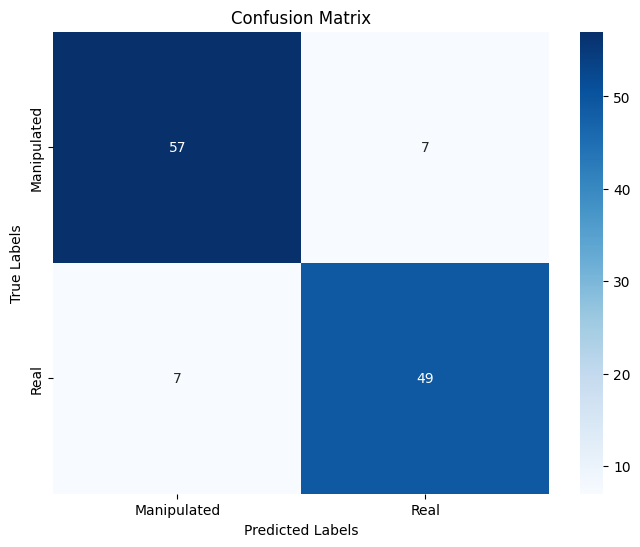

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Print Validation Loss and Accuracy
print(f"📈 Val Loss: {avg_val_loss:.4f}")
print(f"✅ Val Acc: {val_acc:.2f}%")

# Classification Report
print("\n🧾 Classification Report:")
print(classification_report(
    [idx_to_class[i] for i in true_labels],
    [idx_to_class[i] for i in pred_labels],
    digits=3
))

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Manipulated', 'Real'], yticklabels=['Manipulated', 'Real'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
best_model = "/content/drive/MyDrive/ModelTrain/Sexual_Harassment/checkpoints/best_model.pth"

In [ ]:
# Make sure num_classes is still set correctly
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model.load_state_dict(torch.load(best_model))
model.eval()
model.to(device)

VideoMAEForVideoClassification(
  (videomae): VideoMAEModel(
    (embeddings): VideoMAEEmbeddings(
      (patch_embeddings): VideoMAEPatchEmbeddings(
        (projection): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
    )
    (encoder): VideoMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x VideoMAELayer(
          (attention): VideoMAEAttention(
            (attention): VideoMAESelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): VideoMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): VideoMAEIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
    

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluation function
def evaluate(model, dataloader, label_map, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    val_loss = 0
    true_labels = []
    pred_labels = []

    with torch.no_grad():
        for pixel_values, labels in dataloader:
            pixel_values = pixel_values.to(device)
            labels = labels.to(device)

            outputs = model(pixel_values=pixel_values)
            loss = criterion(outputs.logits, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            true_labels.extend(labels.cpu().numpy())
            pred_labels.extend(preds.cpu().numpy())

    avg_loss = val_loss / len(dataloader)
    accuracy = accuracy_score(true_labels, pred_labels)

    # Convert index to class names
    idx_to_class = {v: k for k, v in label_map.items()}
    true_class_names = [idx_to_class[i] for i in true_labels]
    pred_class_names = [idx_to_class[i] for i in pred_labels]

    # Classification report
    report = classification_report(true_class_names, pred_class_names, digits=3)

    return avg_loss, accuracy, report, true_class_names, pred_class_names


Validation Accuracy: 90.00%
💾 Validation Loss: 0.3307

🧾 Classification Report:
               precision    recall  f1-score   support

   Harassment      0.879     0.911     0.895        56
No_Harassment      0.919     0.891     0.905        64

     accuracy                          0.900       120
    macro avg      0.899     0.901     0.900       120
 weighted avg      0.901     0.900     0.900       120



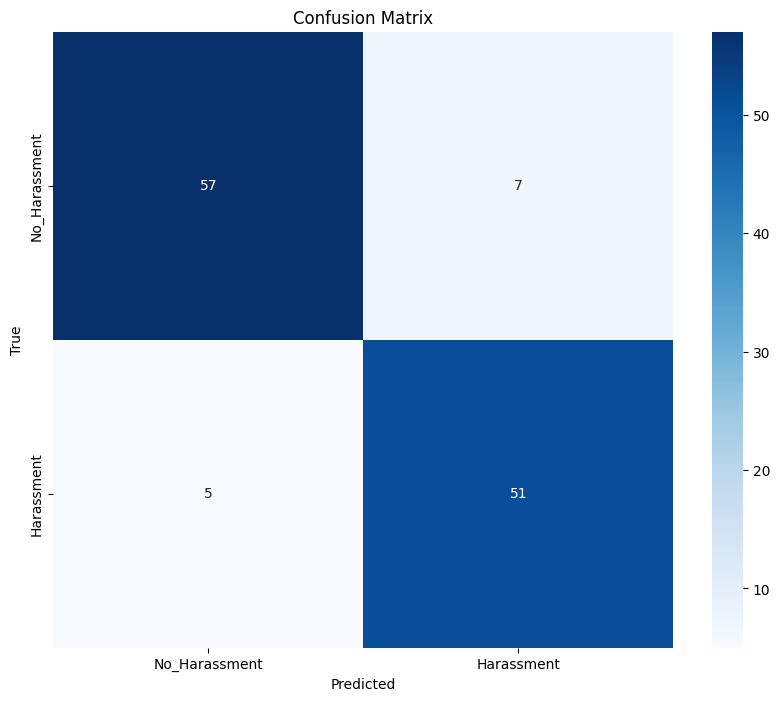

In [ ]:
# Load best model
model.load_state_dict(torch.load(best_model))
model.to(device)
model.eval()

# Run evaluation
avg_test_loss, test_acc, report, true_class_names, pred_class_names = evaluate(model, val_loader, label_map, device)

# Print results
print(f"Validation Accuracy: {test_acc * 100:.2f}%")
print(f"💾 Validation Loss: {avg_test_loss:.4f}")
print("\n🧾 Classification Report:")
print(report)

# Plot Confusion Matrix
idx_to_class = {v: k for k, v in label_map.items()}
class_names = list(idx_to_class.values())

cm = confusion_matrix(true_class_names, pred_class_names, labels=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

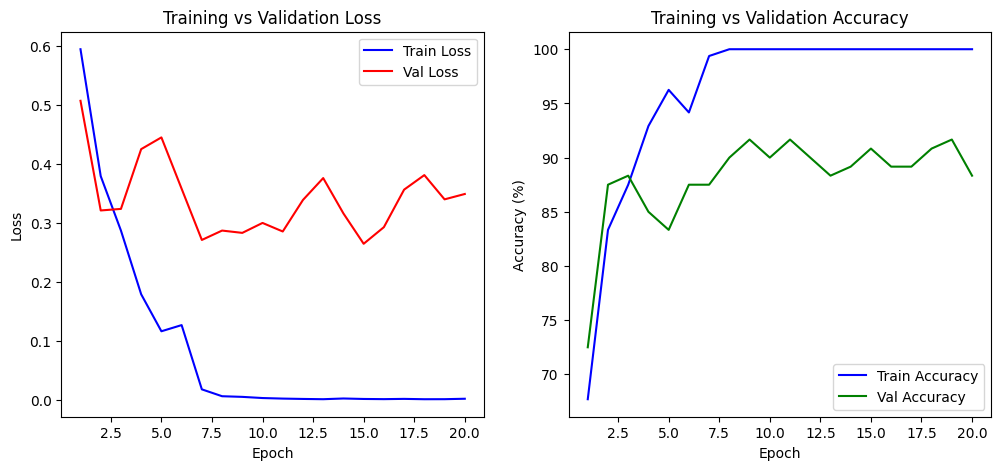

In [ ]:
# =====================
# Plot Loss & Accuracy Curves
# =====================
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,5))

# ----- Loss Curve -----
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'b-', label='Train Loss')
plt.plot(epochs, val_losses, 'r-', label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# ----- Accuracy Curve -----
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, 'b-', label='Train Accuracy')
plt.plot(epochs, val_accuracies, 'g-', label='Val Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
def predict_video(video_path, model, feature_extractor, label_map, num_frames=16):
    # Load video frames
    vr = VideoReader(video_path, ctx=cpu(0))
    total_frames = len(vr)
    indices = np.linspace(0, total_frames - 1, min(num_frames, total_frames)).astype(int)
    frames = vr.get_batch(indices).asnumpy()

    # Preprocess
    inputs = feature_extractor(list(frames), return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    # Inference
    with torch.no_grad():
        outputs = model(pixel_values)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        pred_class_idx = torch.argmax(probs, dim=1).item()

    # Map index to class name
    class_name = [k for k, v in label_map.items() if v == pred_class_idx][0]
    confidence = probs[0][pred_class_idx].item()
    return class_name, confidence

In [ ]:
video_path = "/content/Sexual_Harassment_Dataset/Harassment_dataset/Harassment/haras_1.mp4"  # <-- change this to your actual file
pred_class, confidence = predict_video(video_path, model, feature_extractor, label_map)
print(f"Predicted: {pred_class} ({confidence*100:.1f}%)")

Predicted: Harassment (99.5%)


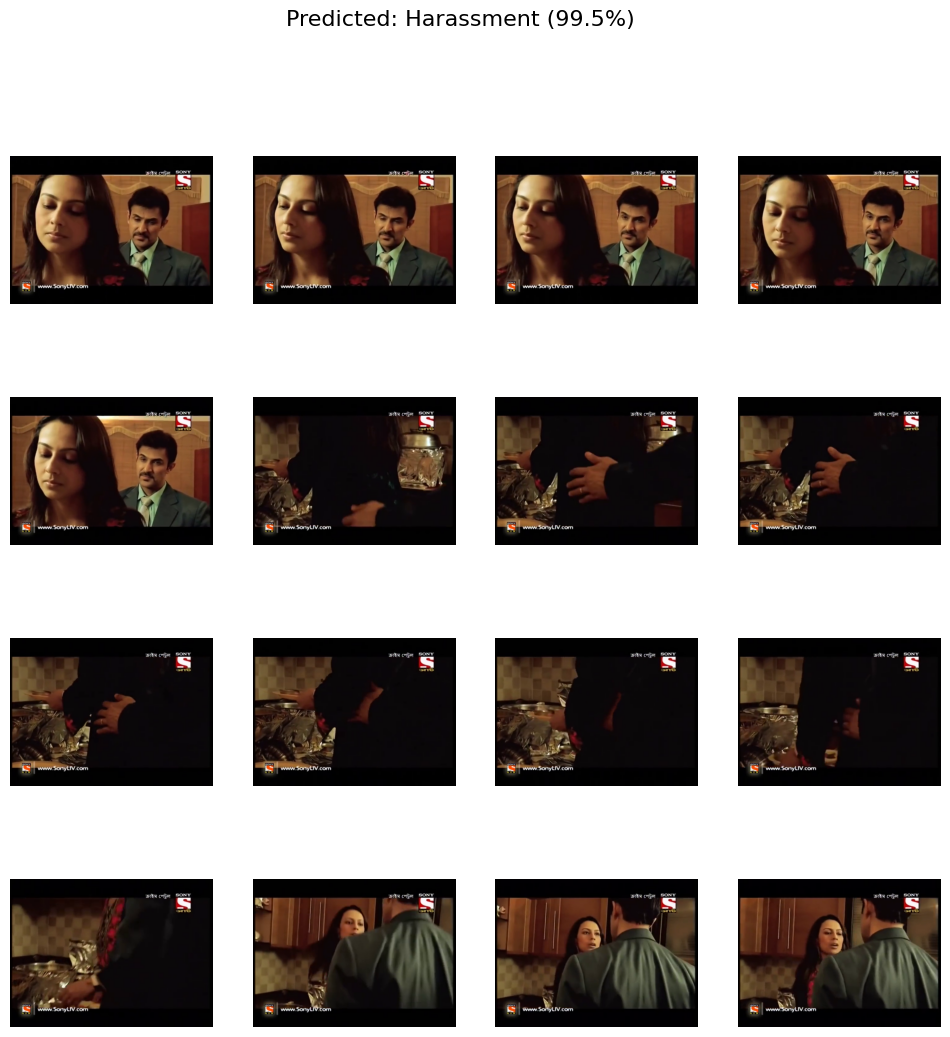

In [ ]:
# Re-run the prediction to ensure pred_class and confidence are defined
pred_class, confidence = predict_video(video_path, model, feature_extractor, label_map)

vr = VideoReader(video_path, ctx=cpu(0))
frames = vr.get_batch(np.linspace(0, len(vr)-1, 16).astype(int)).asnumpy()

import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(frames[i])
    ax.axis('off')
plt.suptitle(f"Predicted: {pred_class} ({confidence*100:.1f}%)", fontsize=16)
plt.show()

In [ ]:
import os
from collections import defaultdict

# ANSI color codes
RED = "\033[91m"
RESET = "\033[0m"

dataset_root = "/content/Sexual_Harassment_Dataset/Harassment_dataset"

# Track incorrect/correct counts per class
incorrect_counts = defaultdict(int)
total_counts = defaultdict(int)

# Track global totals
total_videos = 0
total_correct = 0

for class_folder in os.listdir(dataset_root):
    folder_path = os.path.join(dataset_root, class_folder)
    if not os.path.isdir(folder_path):
        continue

    print(f"\n📂 Class folder: {class_folder}")

    for video_file in os.listdir(folder_path):
        if not video_file.endswith(".mp4"):
            continue

        video_path = os.path.join(folder_path, video_file)

        try:
            pred_class, confidence = predict_video(video_path, model, feature_extractor, label_map)
            total_counts[class_folder] += 1
            total_videos += 1

            if pred_class != class_folder:
                incorrect_counts[class_folder] += 1
                print(f"{RED}📹 {video_file} → Predicted: {pred_class} ({confidence*100:.1f}%) [Expected: {class_folder}]{RESET}")
            else:
                total_correct += 1
                print(f"📹 {video_file} → Predicted: {pred_class} ({confidence*100:.1f}%)")

        except Exception as e:
            print(f"⚠️ Failed on {video_file}: {e}")

# 🔢 Summary of incorrect predictions
print("\n📊 Class-wise Prediction Summary:")
for class_name in sorted(total_counts):
    total = total_counts[class_name]
    incorrect = incorrect_counts[class_name]
    correct = total - incorrect
    print(f"🔹 {class_name}: {incorrect} incorrect out of {total} → Accuracy: {correct / total * 100:.1f}%")

# 🎯 Total accuracy
if total_videos > 0:
    total_accuracy = total_correct / total_videos * 100
    print(f"\n🎯 Total Accuracy: {total_correct} correct out of {total_videos} → {total_accuracy:.2f}%")
else:
    print("\n⚠️ No videos found to evaluate.")


📂 Class folder: Harassment
📹 haras_75.mp4 → Predicted: Harassment (99.8%)
📹 haras_238.mp4 → Predicted: Harassment (99.4%)
📹 haras_135.mp4 → Predicted: Harassment (100.0%)
📹 haras_157.mp4 → Predicted: Harassment (99.2%)
📹 haras_176.mp4 → Predicted: Harassment (100.0%)
📹 haras_29.mp4 → Predicted: Harassment (99.9%)
📹 haras_197.mp4 → Predicted: Harassment (99.9%)
📹 haras_110.mp4 → Predicted: Harassment (67.9%)
📹 haras_251.mp4 → Predicted: Harassment (99.9%)
📹 haras_63.mp4 → Predicted: Harassment (99.8%)
📹 haras_106.mp4 → Predicted: Harassment (100.0%)
📹 haras_265.mp4 → Predicted: Harassment (100.0%)
📹 haras_19.mp4 → Predicted: Harassment (99.6%)
📹 haras_44.mp4 → Predicted: Harassment (99.4%)
📹 haras_117.mp4 → Predicted: Harassment (99.0%)
📹 haras_140.mp4 → Predicted: Harassment (100.0%)
📹 haras_131.mp4 → Predicted: Harassment (99.5%)
📹 haras_198.mp4 → Predicted: No_Harassment (72.8%) [Expected: Harassment]
📹 haras_244.mp4 → Predicted: Harassment (99.9%)
📹 haras_202.mp4 → Predicted: Haras